In [1]:
import arviz as az
import matplotlib.pylab as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
from IPython.core.pylabtools import figsize
from numpy.core.defchararray import upper

from code.Chp_01 import sigmas

In [2]:
az.style.use('arviz-grayscale')
from cycler import cycler
default_cycler = cycler(color=['#000000', '#6a6a6a', '#bebebe', '#2a2eec'])
plt.rc('axes', prop_cycle=default_cycler)
plt.rc('figure', dpi=300, figsize=(12, 4))

In [3]:
# Create sample data of 4 coin flips
np.random.seed(123)
trials = 4
theta_real = 0.35
data = pz.Binomial(n=1, p=theta_real).rvs(trials)
data

array([0, 1, 1, 0])

In [4]:
with pm.Model() as our_first_model:
    θ = pm.Beta('θ', alpha=1.0, beta=1.0)
    y = pm.Bernoulli('y', p=θ, observed=data)
    idata = pm.sample(1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


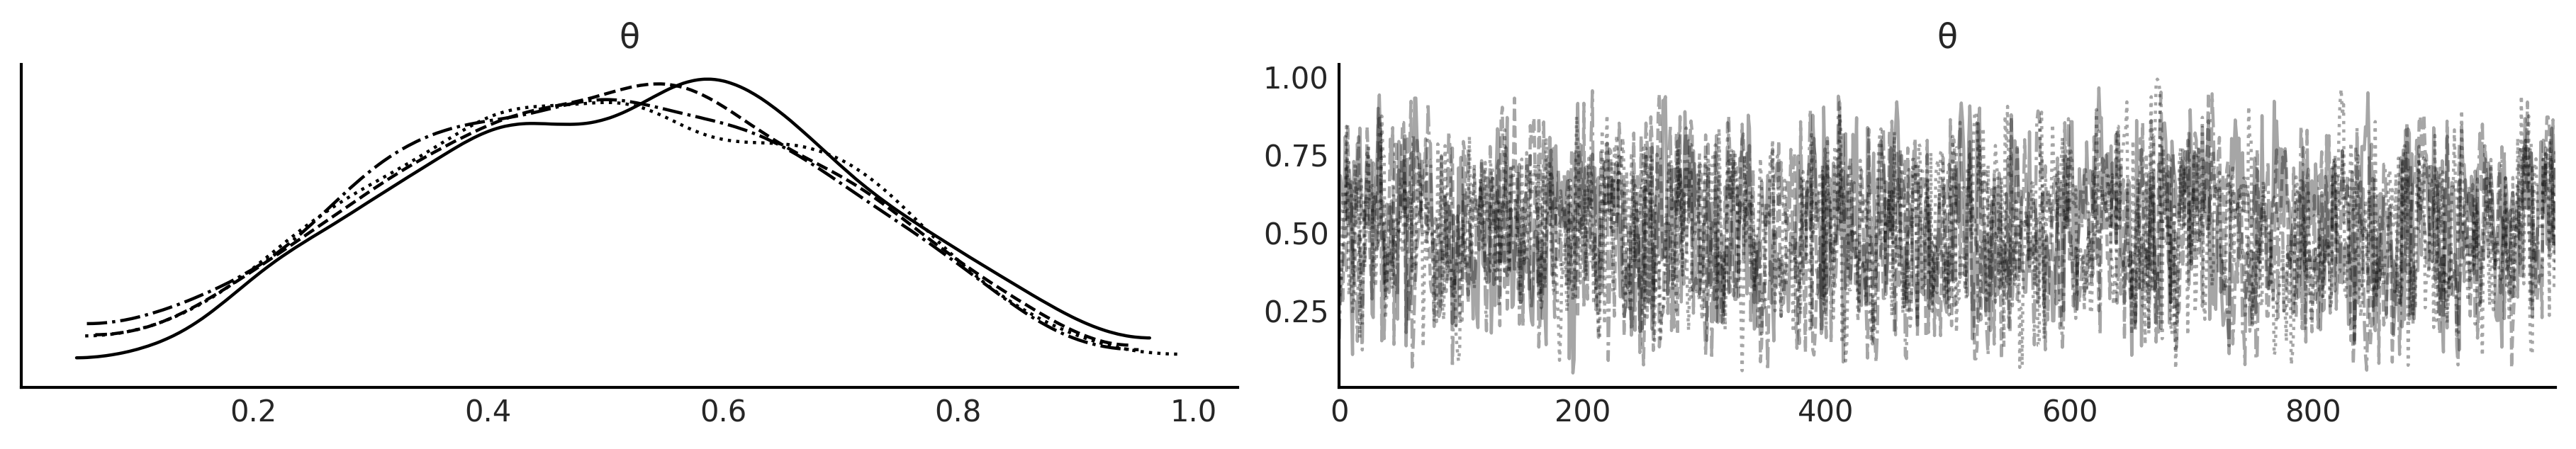

In [5]:
az.plot_trace(idata)
plt.savefig('fig/idata_trace.png')

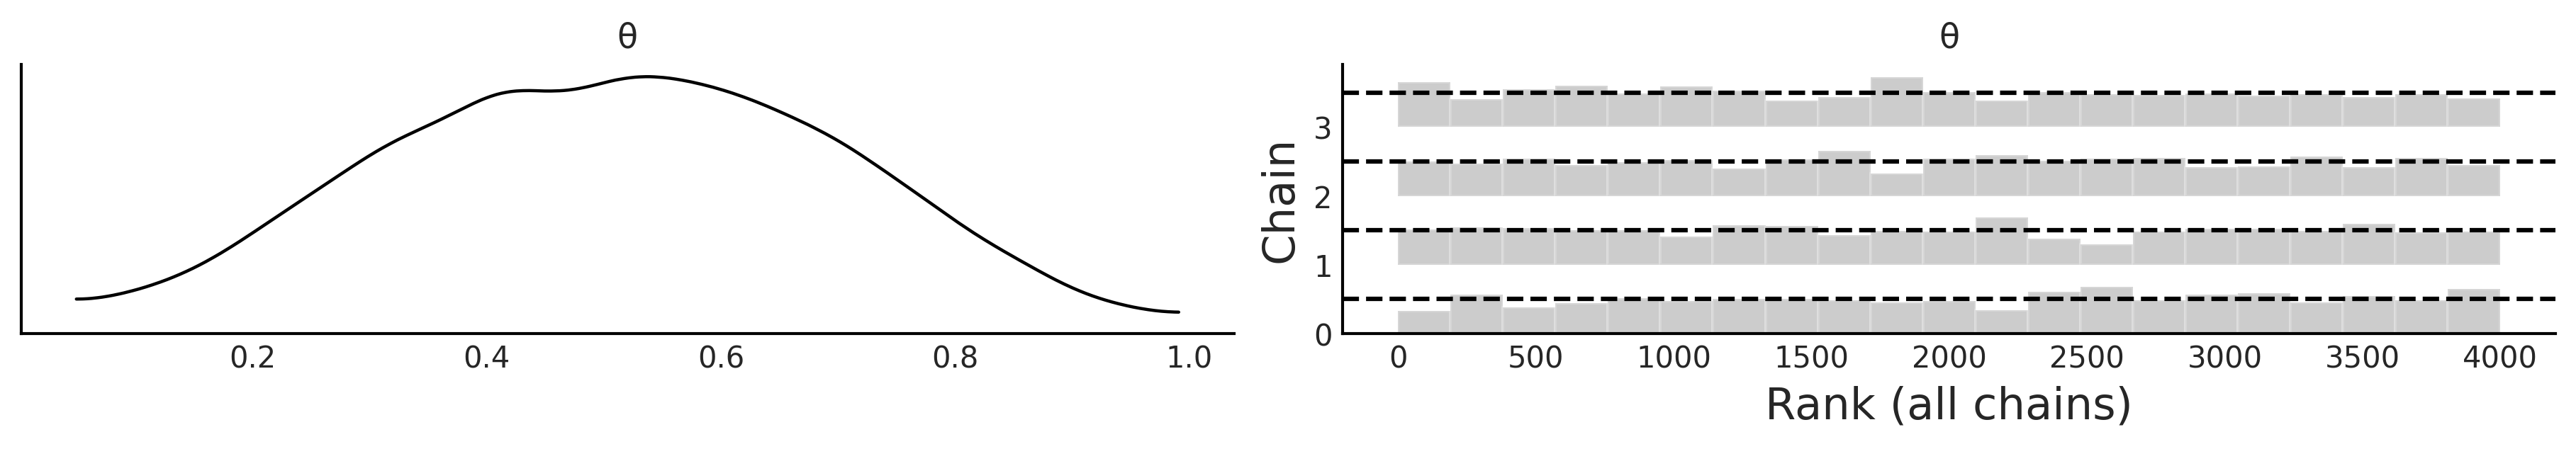

In [6]:
az.plot_trace(idata, kind='rank_bars', combined=True, rank_kwargs={'colors': 'k'})
plt.savefig('fig/idata_rank.png')

In [7]:
az.summary(idata, kind='stats').round(2)

,mean,sd,hdi_3%,hdi_97%
θ,0.51,0.19,0.18,0.86


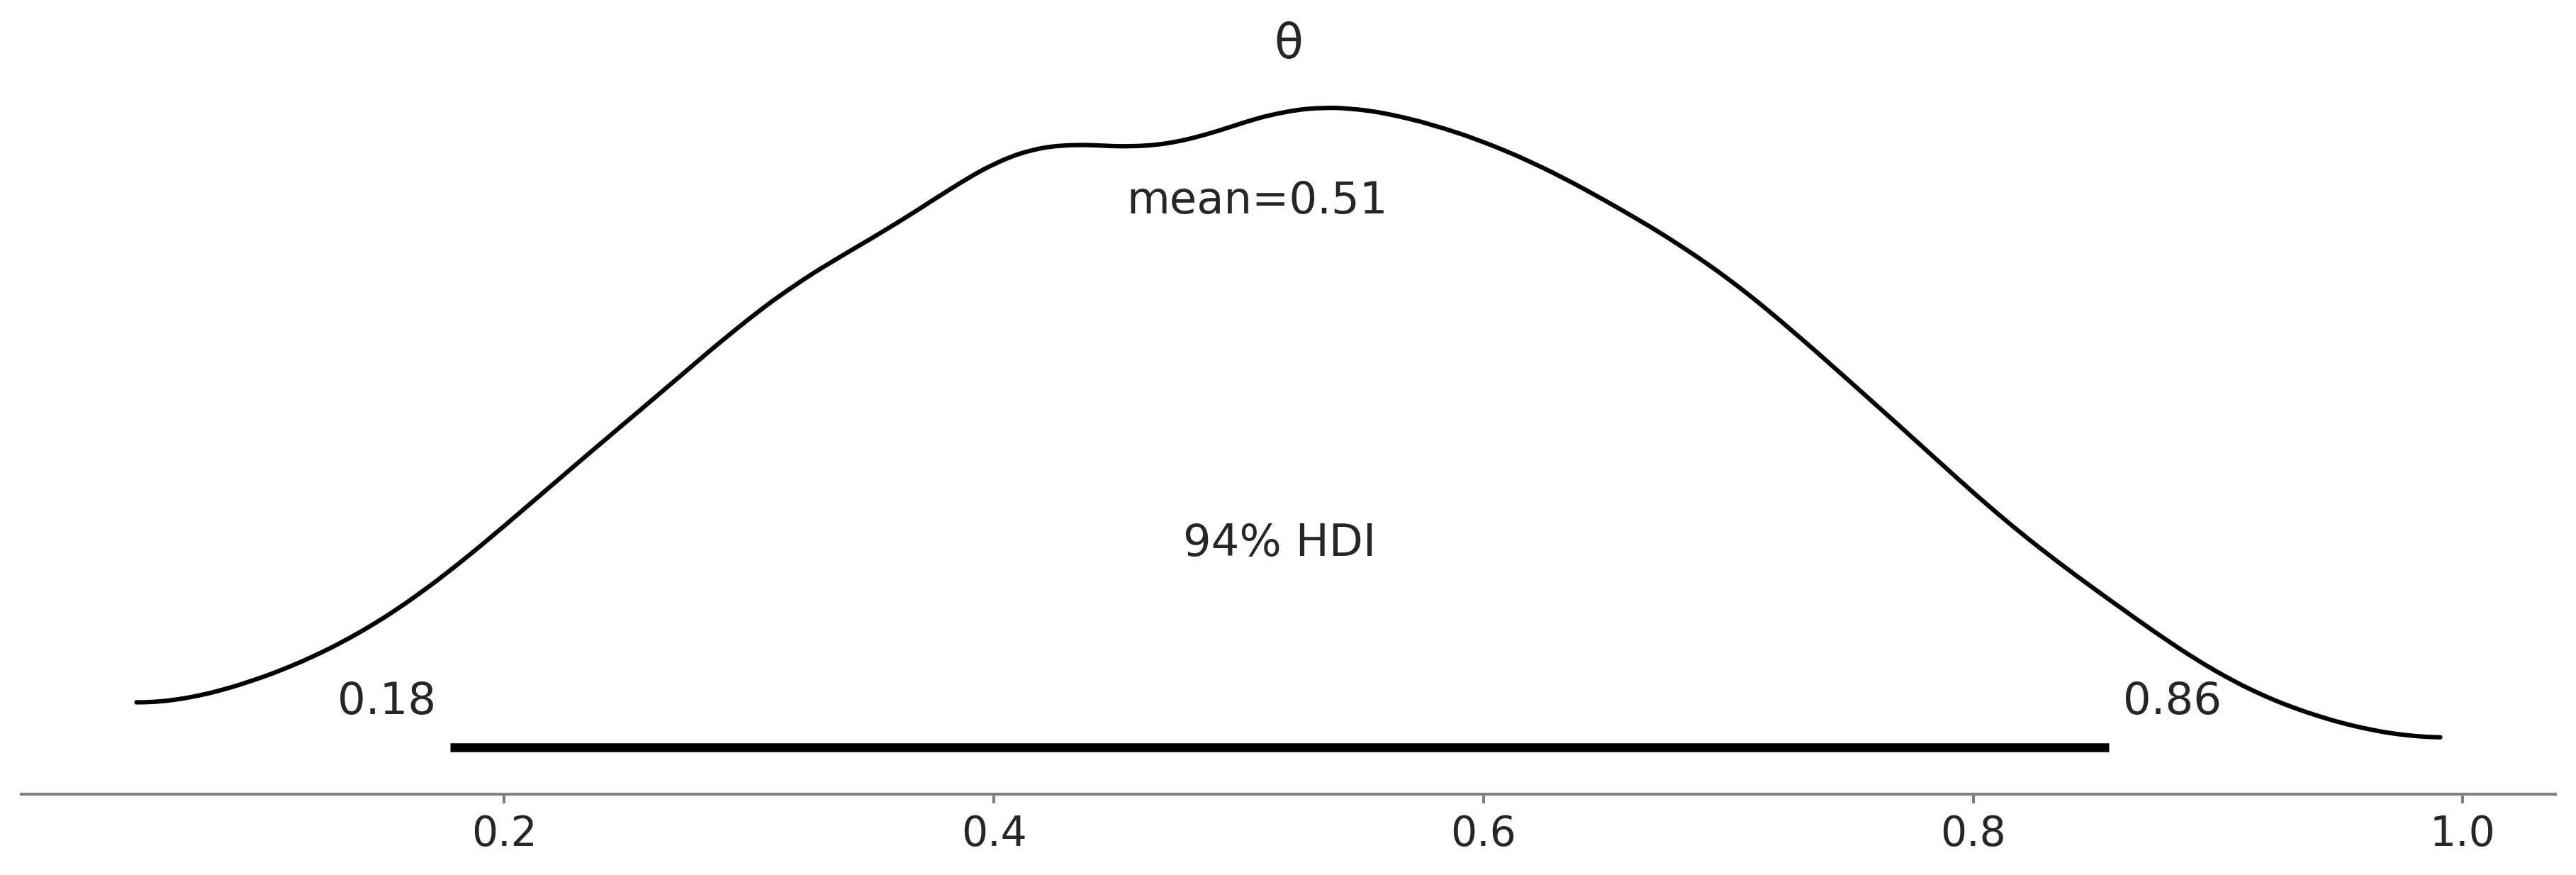

In [8]:
az.plot_posterior(idata, figsize=(12, 4))
plt.savefig('fig/idata_posterior.png')

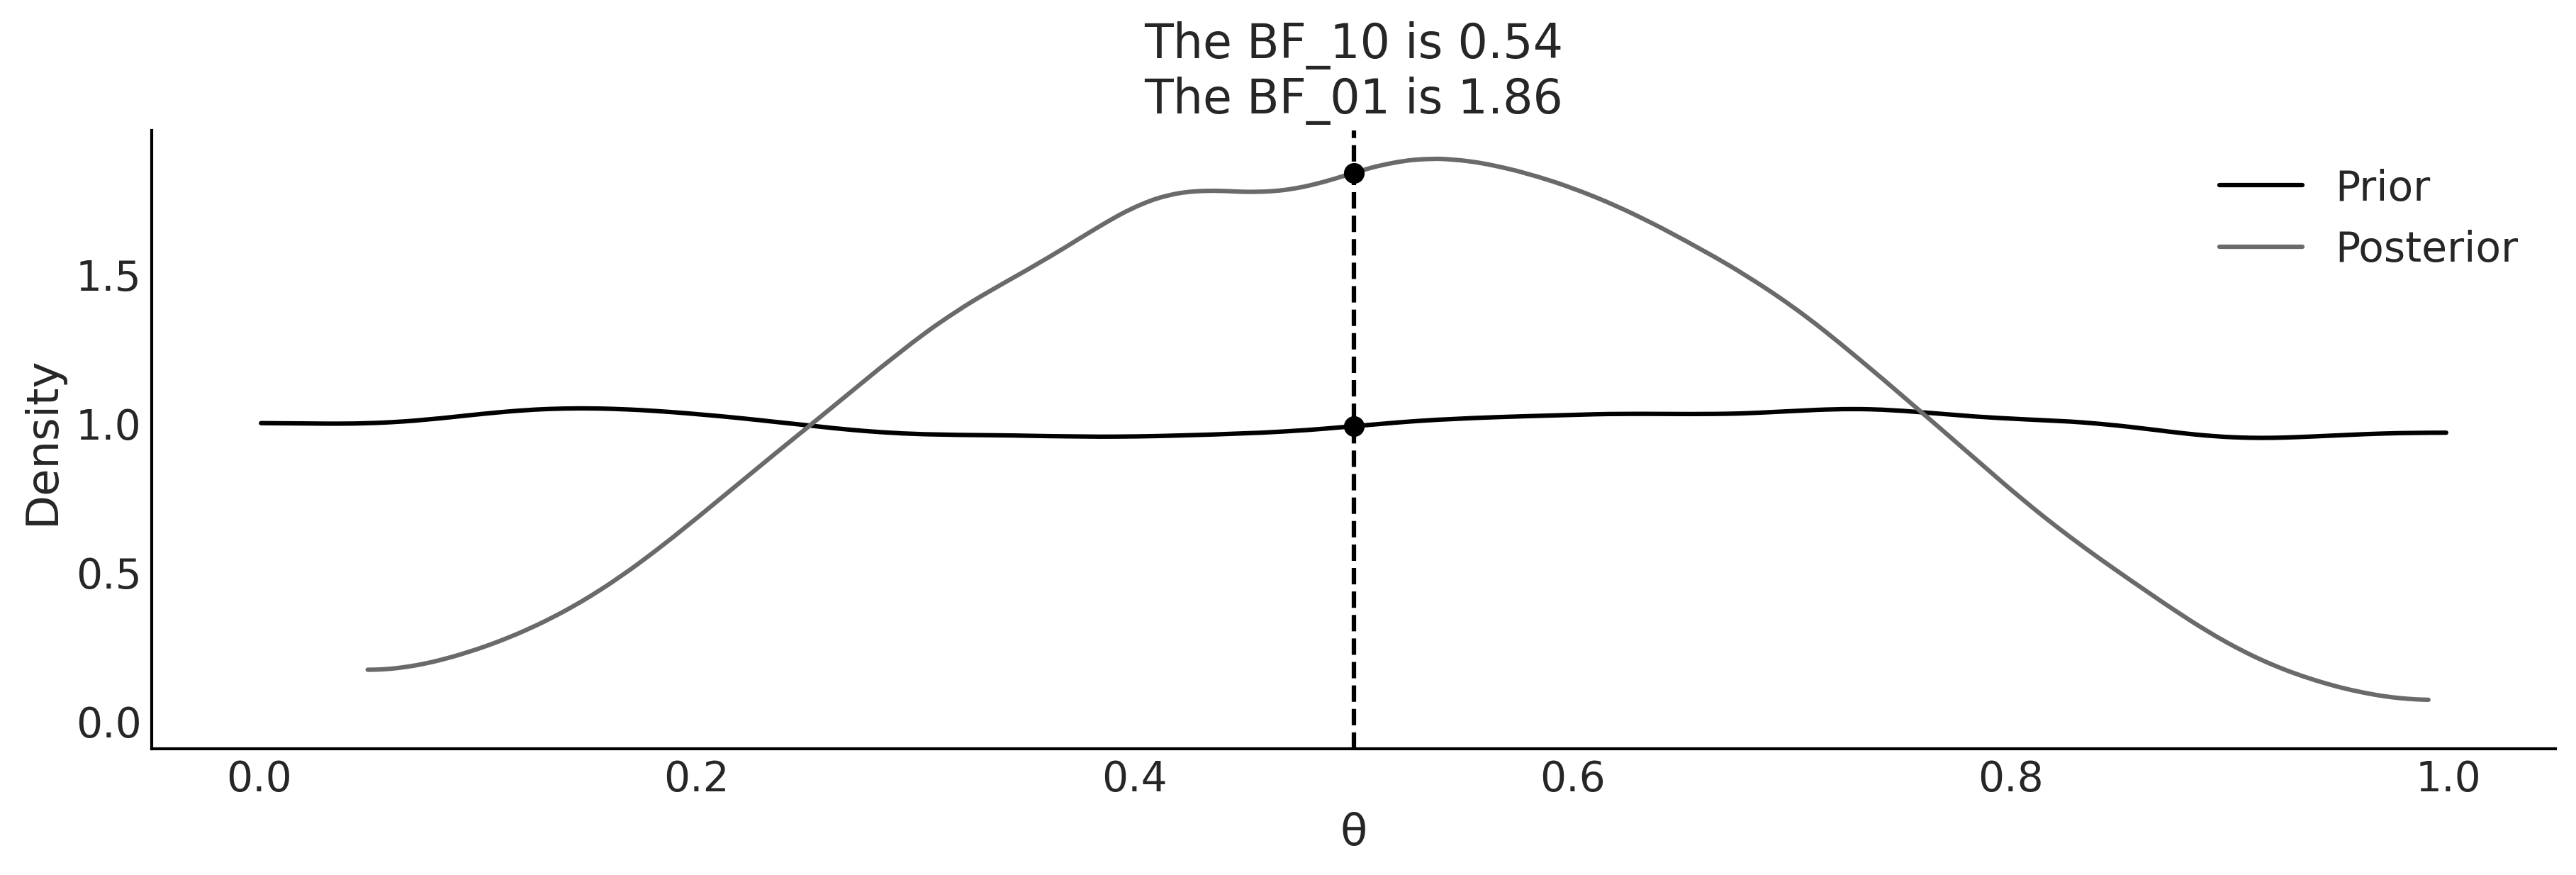

In [9]:
az.plot_bf(idata, var_name='θ', prior=np.random.uniform(0, 1, 10000), ref_val=0.5, figsize=(12, 4), colors=['C0', 'C1'])
plt.savefig('fig/idata_bf.png')

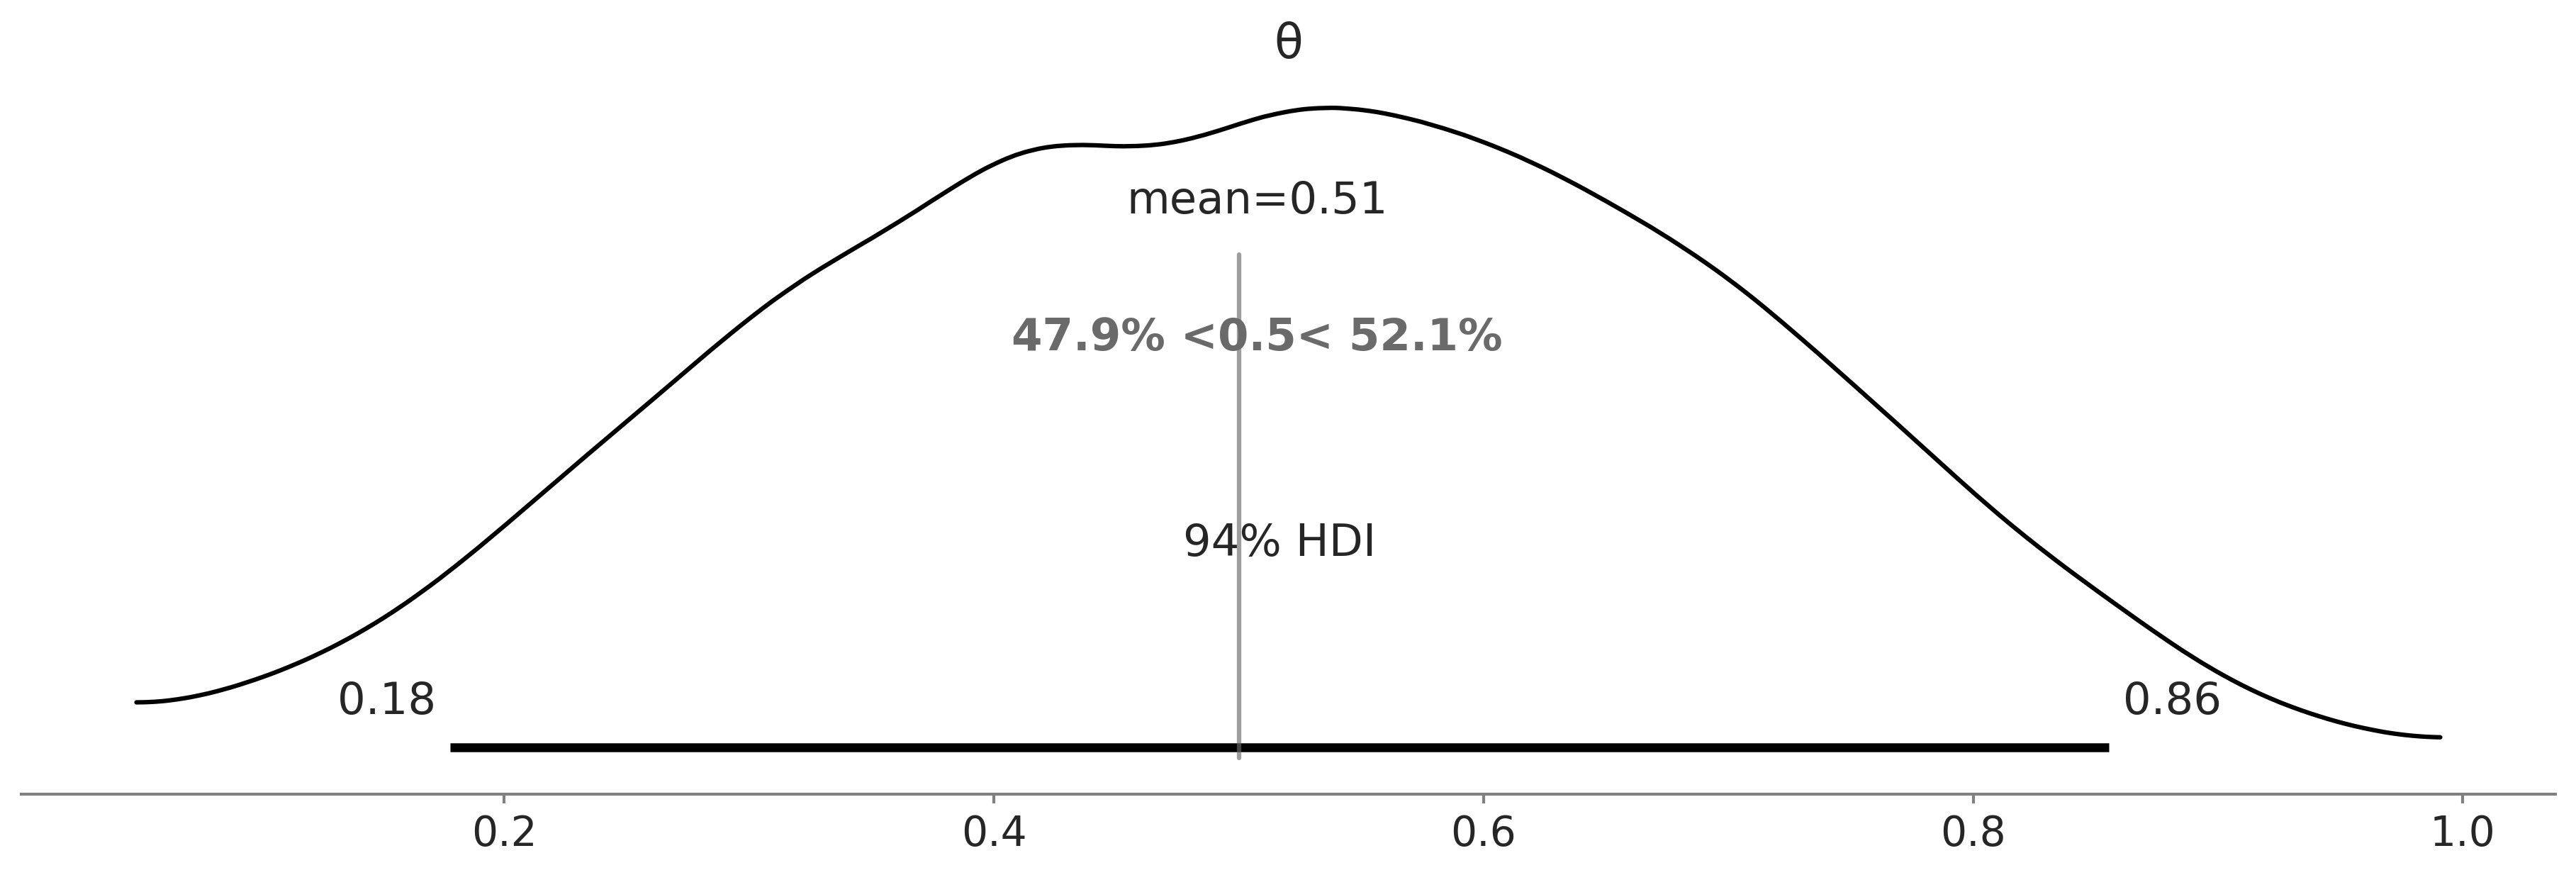

In [10]:
az.plot_posterior(idata, ref_val=0.5, figsize=(12, 4))
plt.savefig('fig/idata_posterior_ref.png')

In [11]:
grid = np.linspace(0, 1, 200)
θ_pos = idata.posterior['θ']
lossf_a = [np.mean(abs(i - θ_pos)) for i in grid]
lossf_b = [np.mean((i - θ_pos)**2) for i in grid]
np.argmin(lossf_a)

102

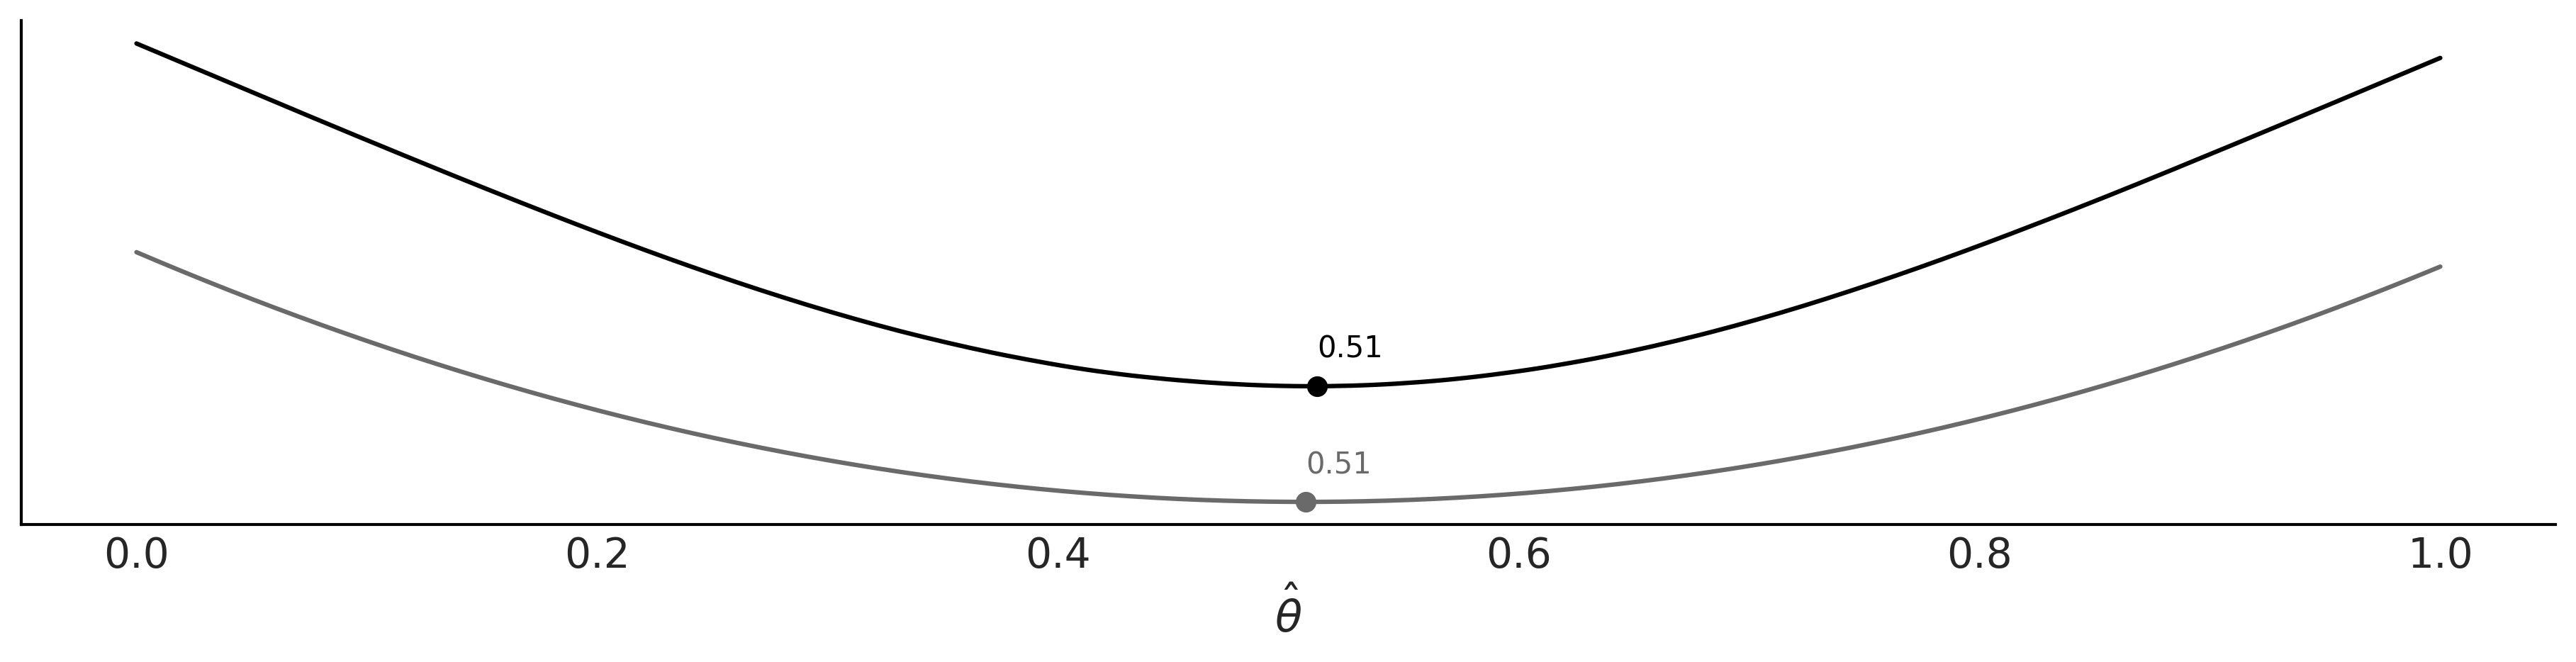

In [12]:
_, ax = plt.subplots(figsize=(12, 3))
for lossf, c in zip([lossf_a, lossf_b], ['C0', 'C1']):
    mini = np.argmin(lossf)
    ax.plot(grid, lossf, c)
    ax.plot(grid[mini], lossf[mini], 'o', color=c)
    ax.annotate('{:.2f}'.format(grid[mini]), (grid[mini], lossf[mini] + 0.03), color=c)

    ax.set_yticks([])
    ax.set_xlabel(r'$\hat \theta$')

plt.savefig('fig/idata_loss.png')

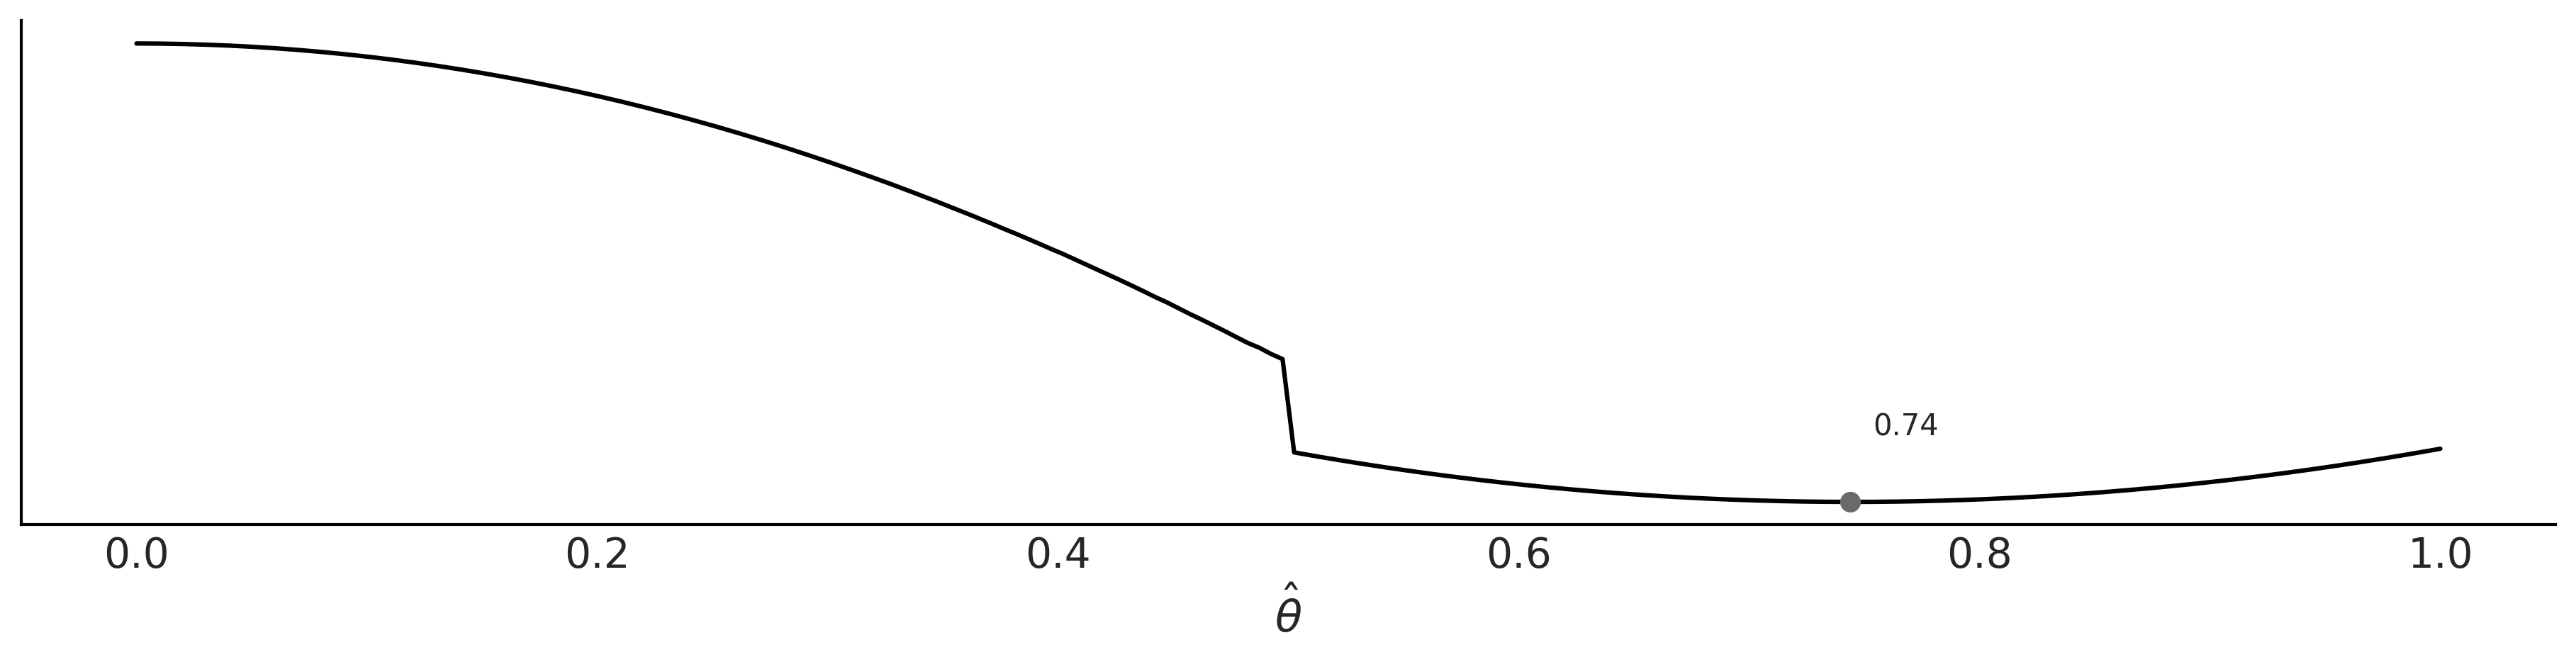

In [13]:
lossf = []
for i in grid:
    if i < 0.5:
        f = 1/np.median(θ_pos / np.abs(i**2 - θ_pos))
    else:
        f = np.mean((i - θ_pos)**2 + np.exp(-i)) - 0.25
    lossf.append(f)

mini = np.argmin(lossf)
_, ax = plt.subplots(figsize=(12, 3))
ax.plot(grid, lossf)
ax.plot(grid[mini], lossf[mini], 'o')
ax.annotate('{:.2f}'.format(grid[mini]), (grid[mini] + 0.01, lossf[mini] + 0.1))
ax.set_yticks([])
ax.set_xlabel(r'$\hat \theta$')

plt.savefig('fig/idata_loss2.png')

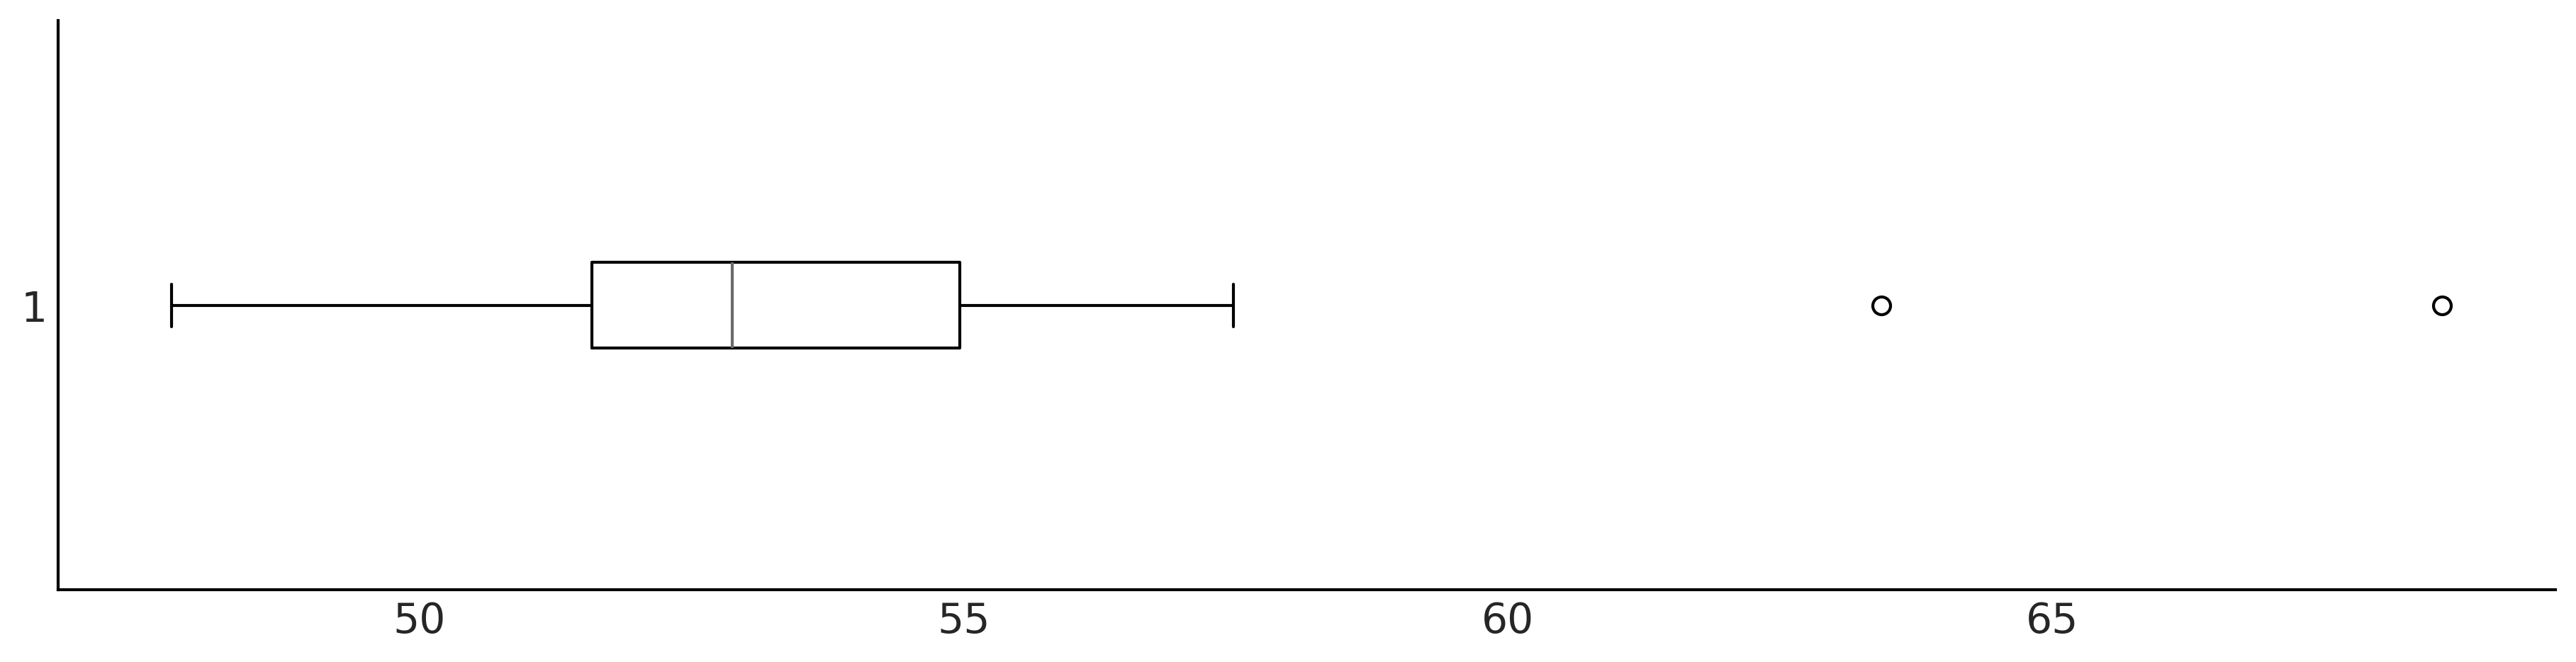

In [14]:
data = np.loadtxt('../code/data/chemical_shifts.csv')
_, ax = plt.subplots(figsize=(12, 3))
ax.boxplot(data, vert=False)
plt.savefig('fig/boxplot.png')

In [16]:
with pm.Model() as model_g:
    µ = pm.Uniform('µ', lower=40, upper=70)
    σ = pm.HalfNormal('σ', sigma=5)
    Y = pm.Normal('Y', mu=µ, sigma=σ, observed=data)
    idata_g = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [µ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


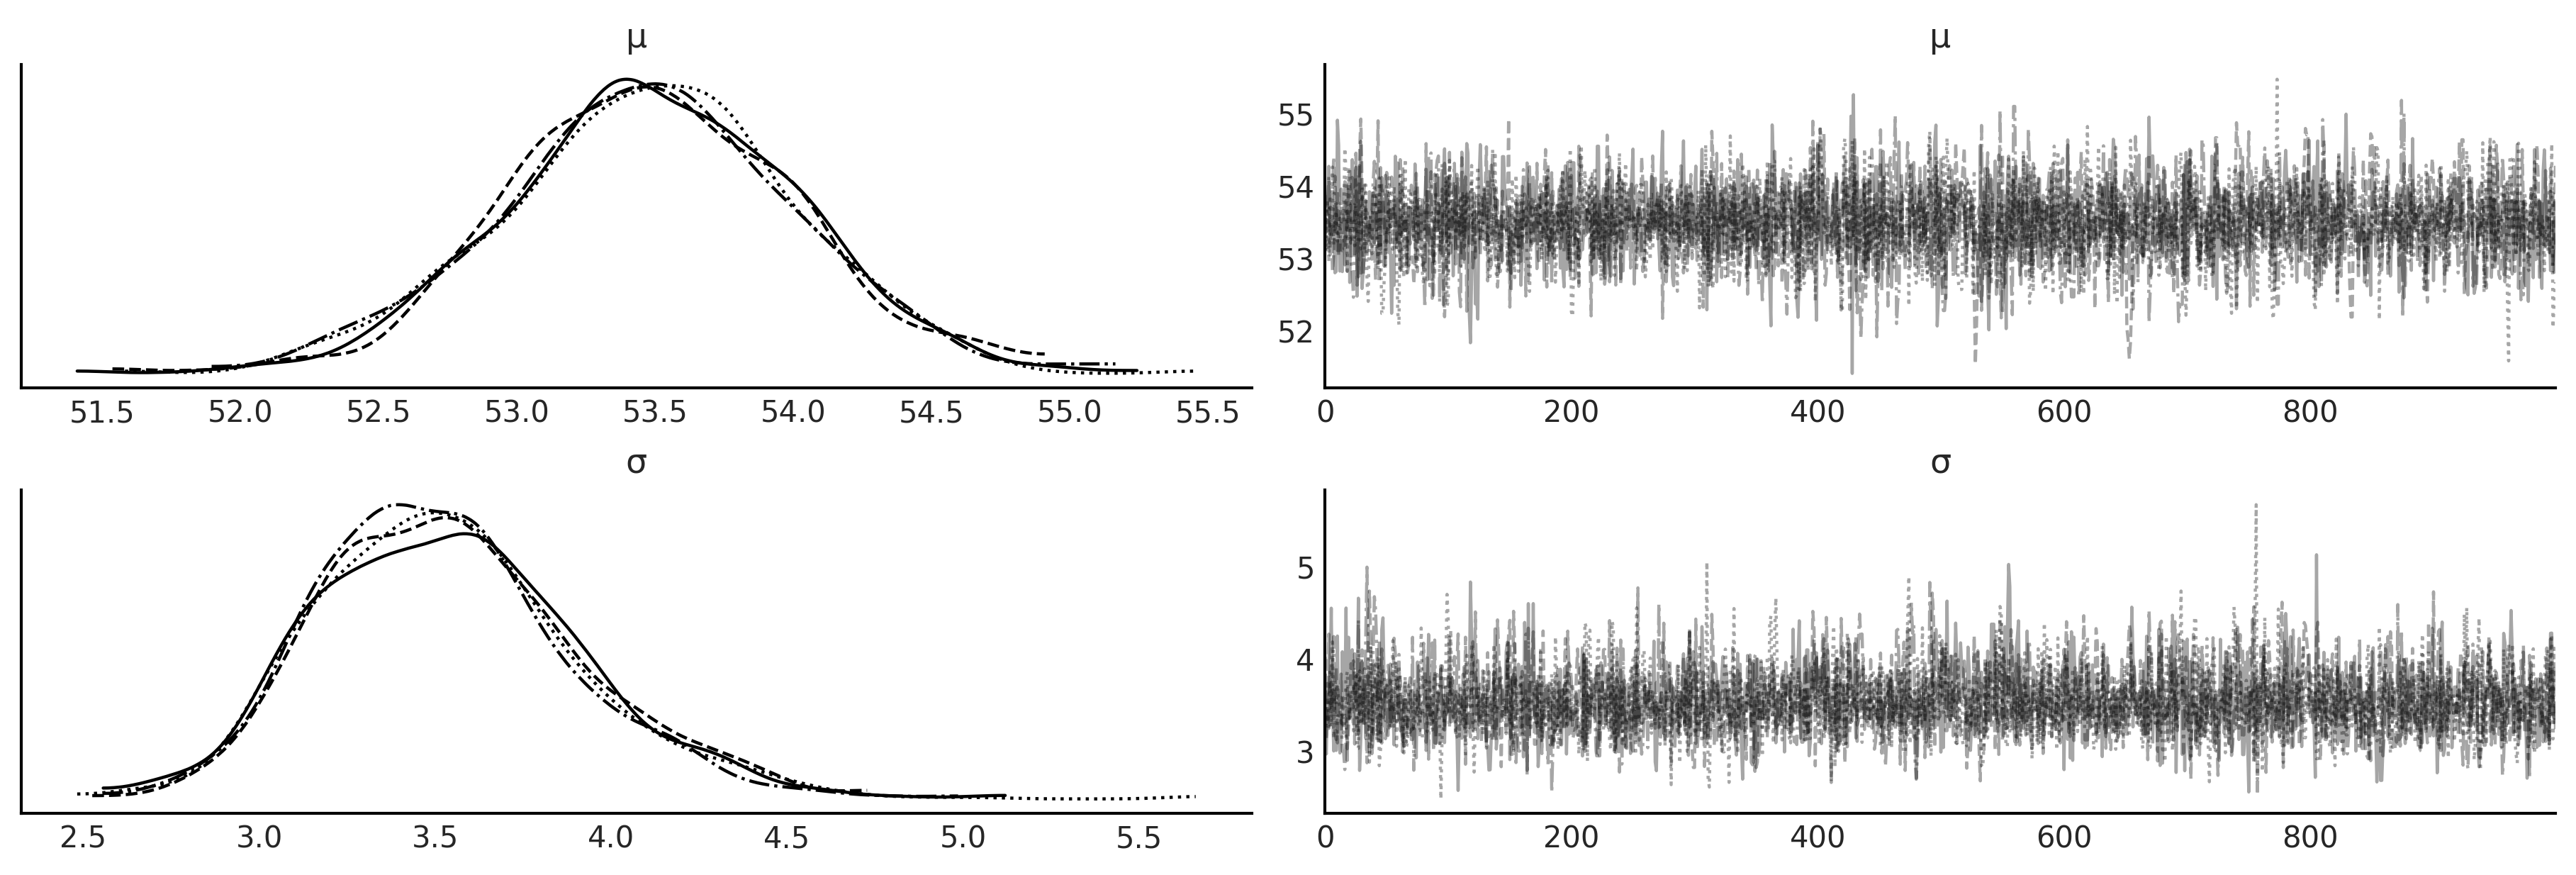

In [18]:
az.plot_trace(idata_g)
plt.savefig('fig/idata_g_trace.png')

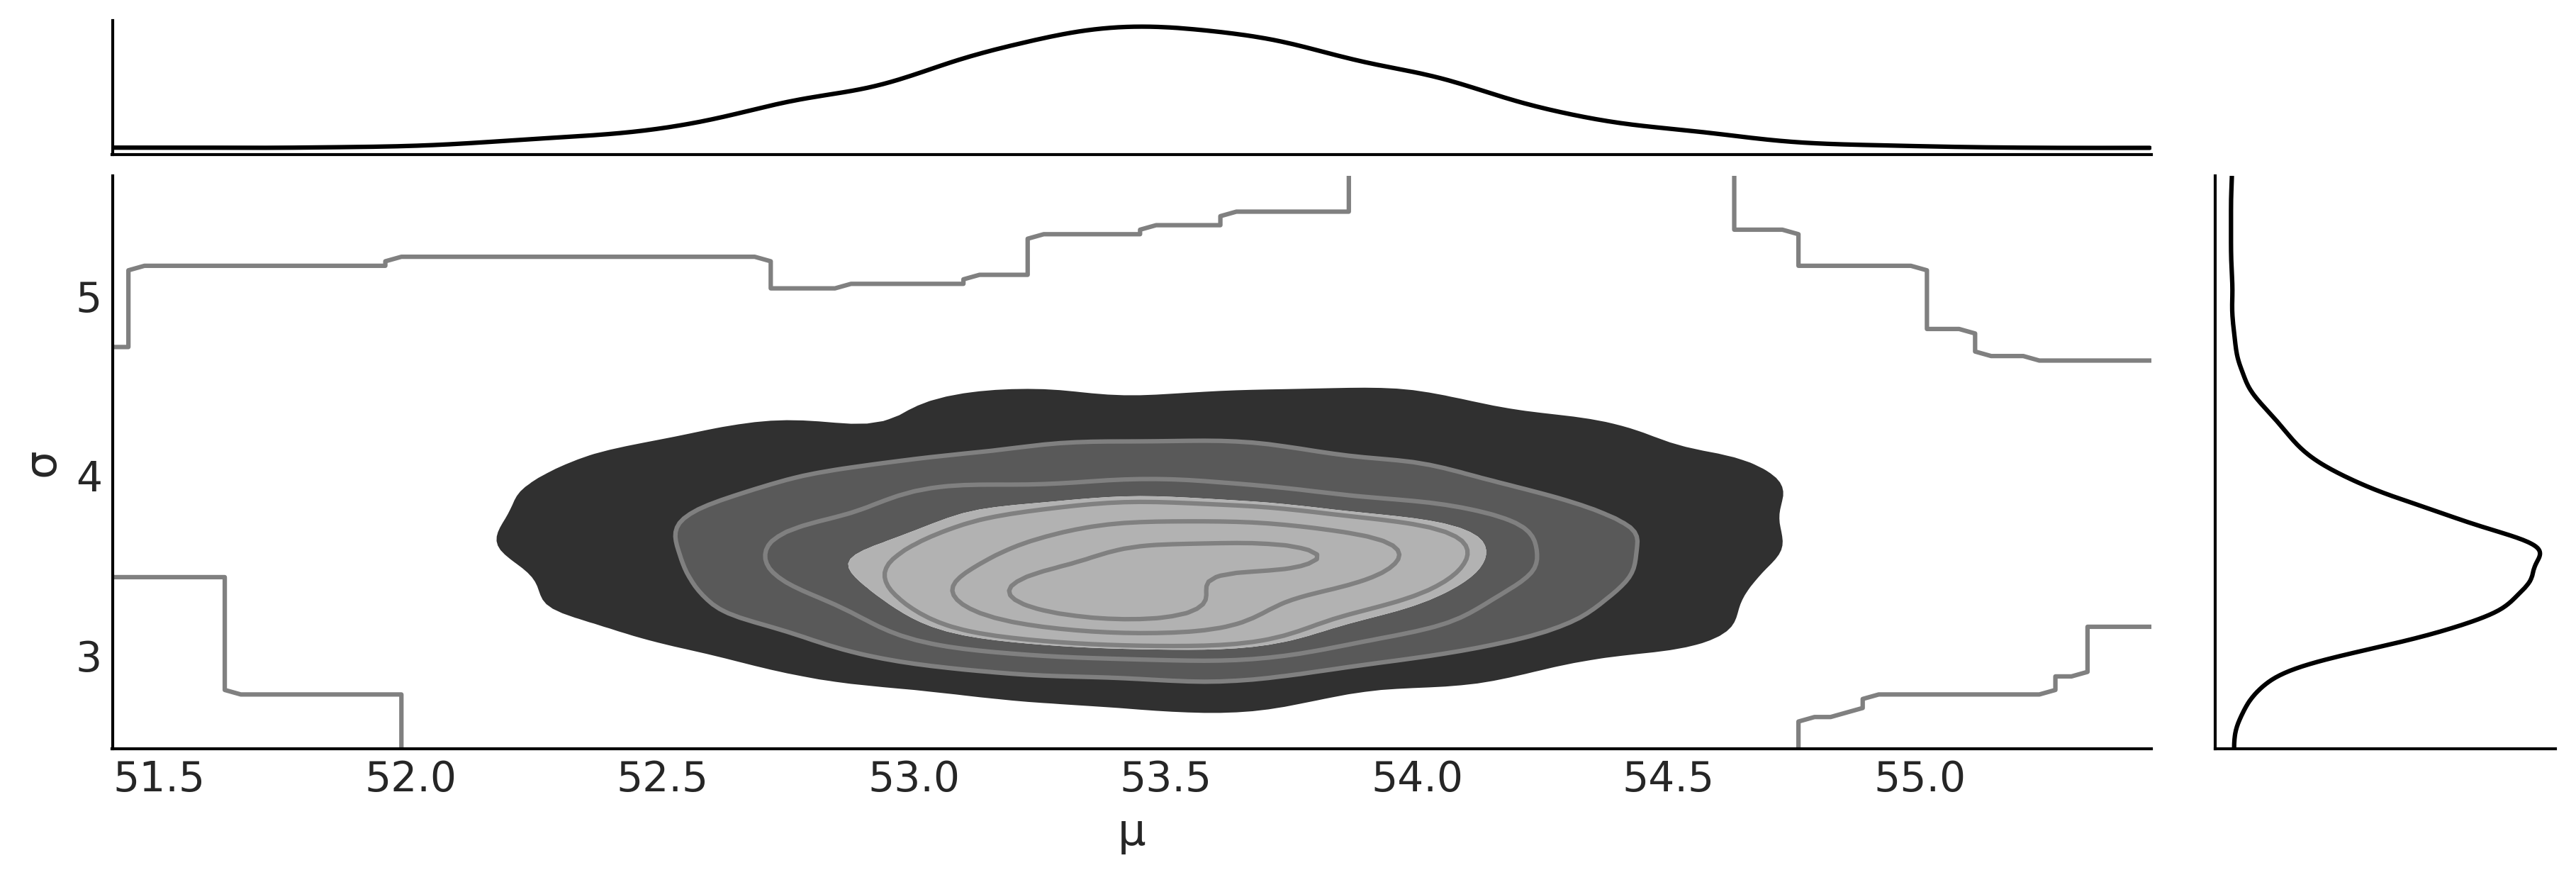

In [19]:
az.plot_pair(idata_g, kind='kde', marginals=True)
plt.savefig('fig/idata_g_pair.png')

In [20]:
az.summary(idata_g, kind='stats').round(2)

,mean,sd,hdi_3%,hdi_97%
µ,53.48,0.52,52.58,54.56
σ,3.53,0.36,2.94,4.30


In [21]:
pm.sample_posterior_predictive(idata_g, model=model_g, extend_inferencedata=True, random_seed=4591)

Sampling: [Y]


Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

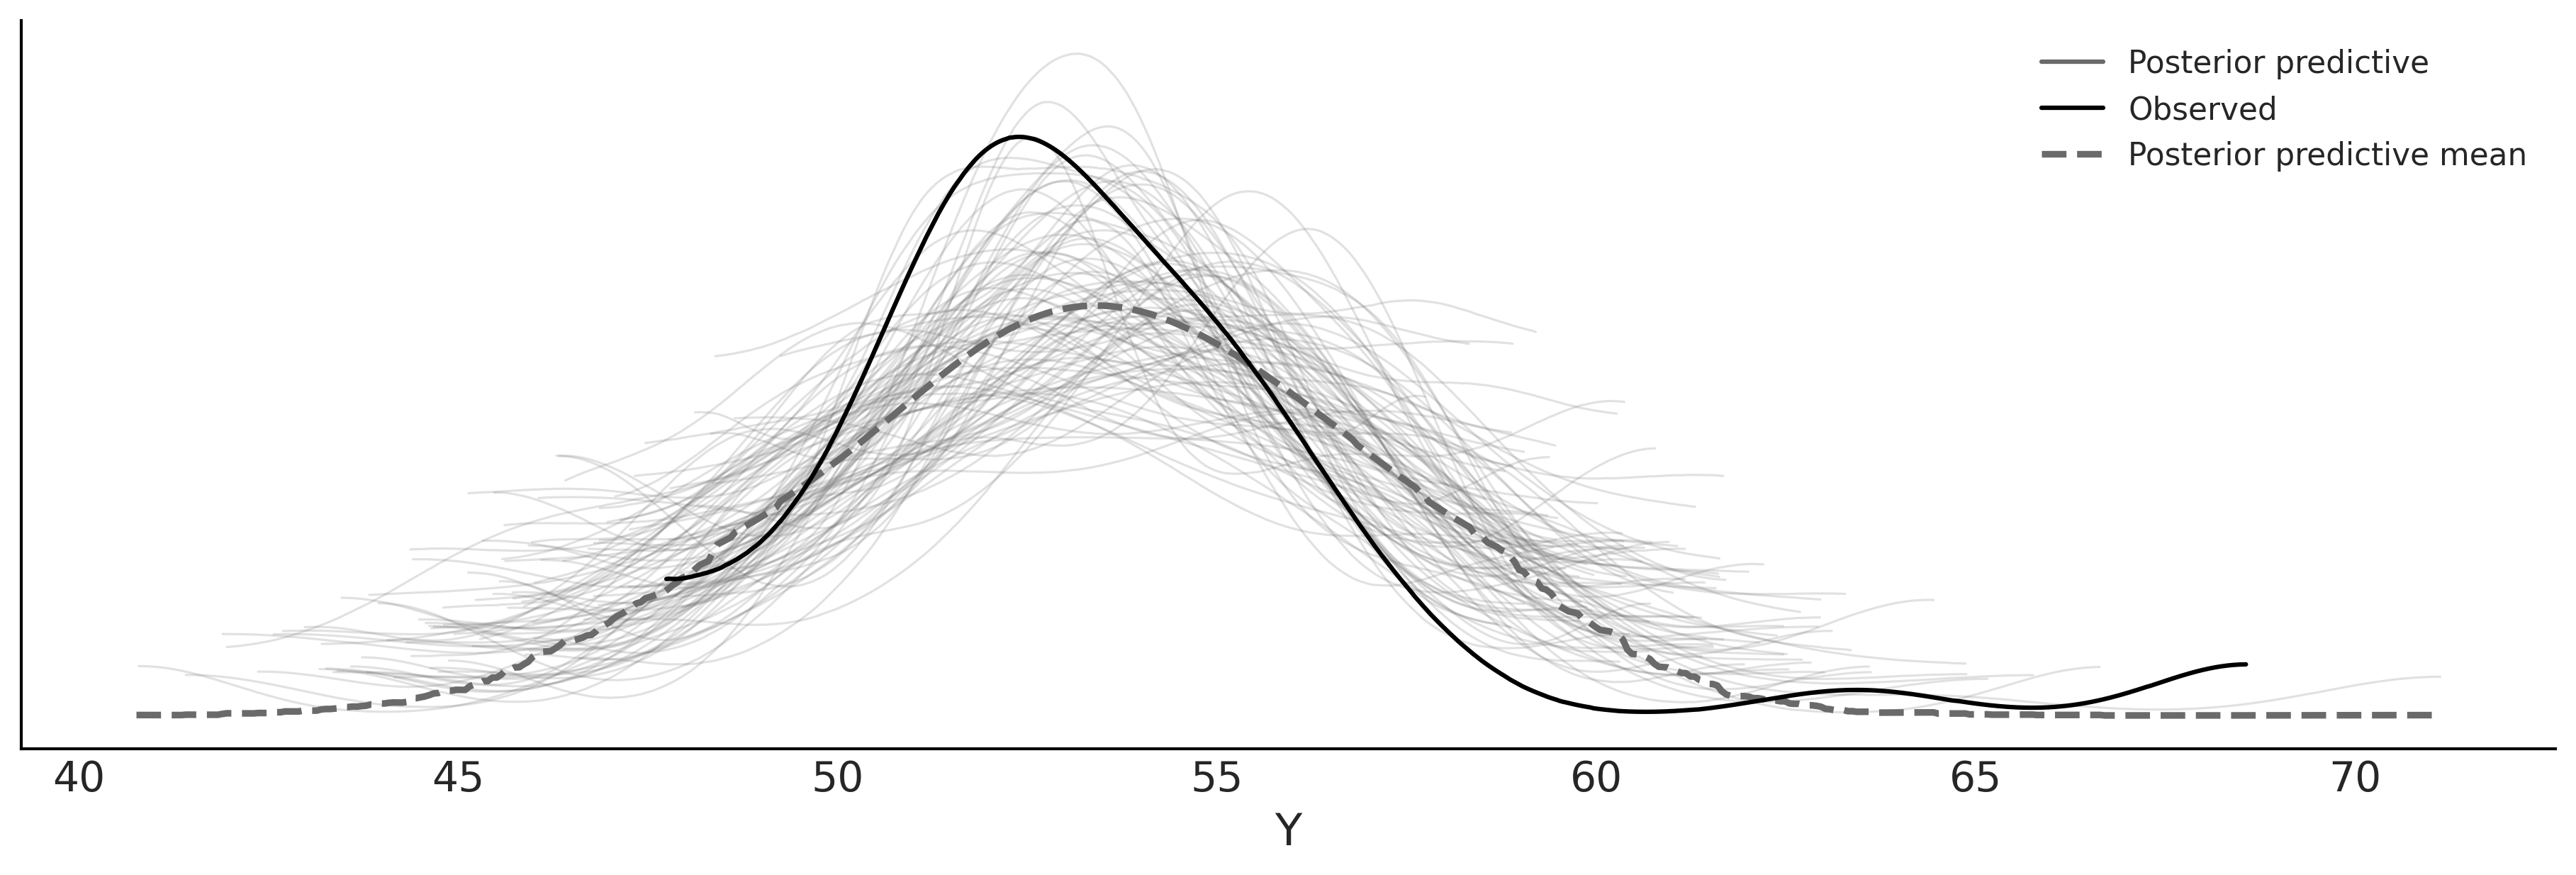

In [23]:
az.plot_ppc(idata_g, num_pp_samples=100, figsize=(12, 4), colors=['C1', 'C0', 'C1'])
plt.savefig('fig/idata_g_ppc.png')

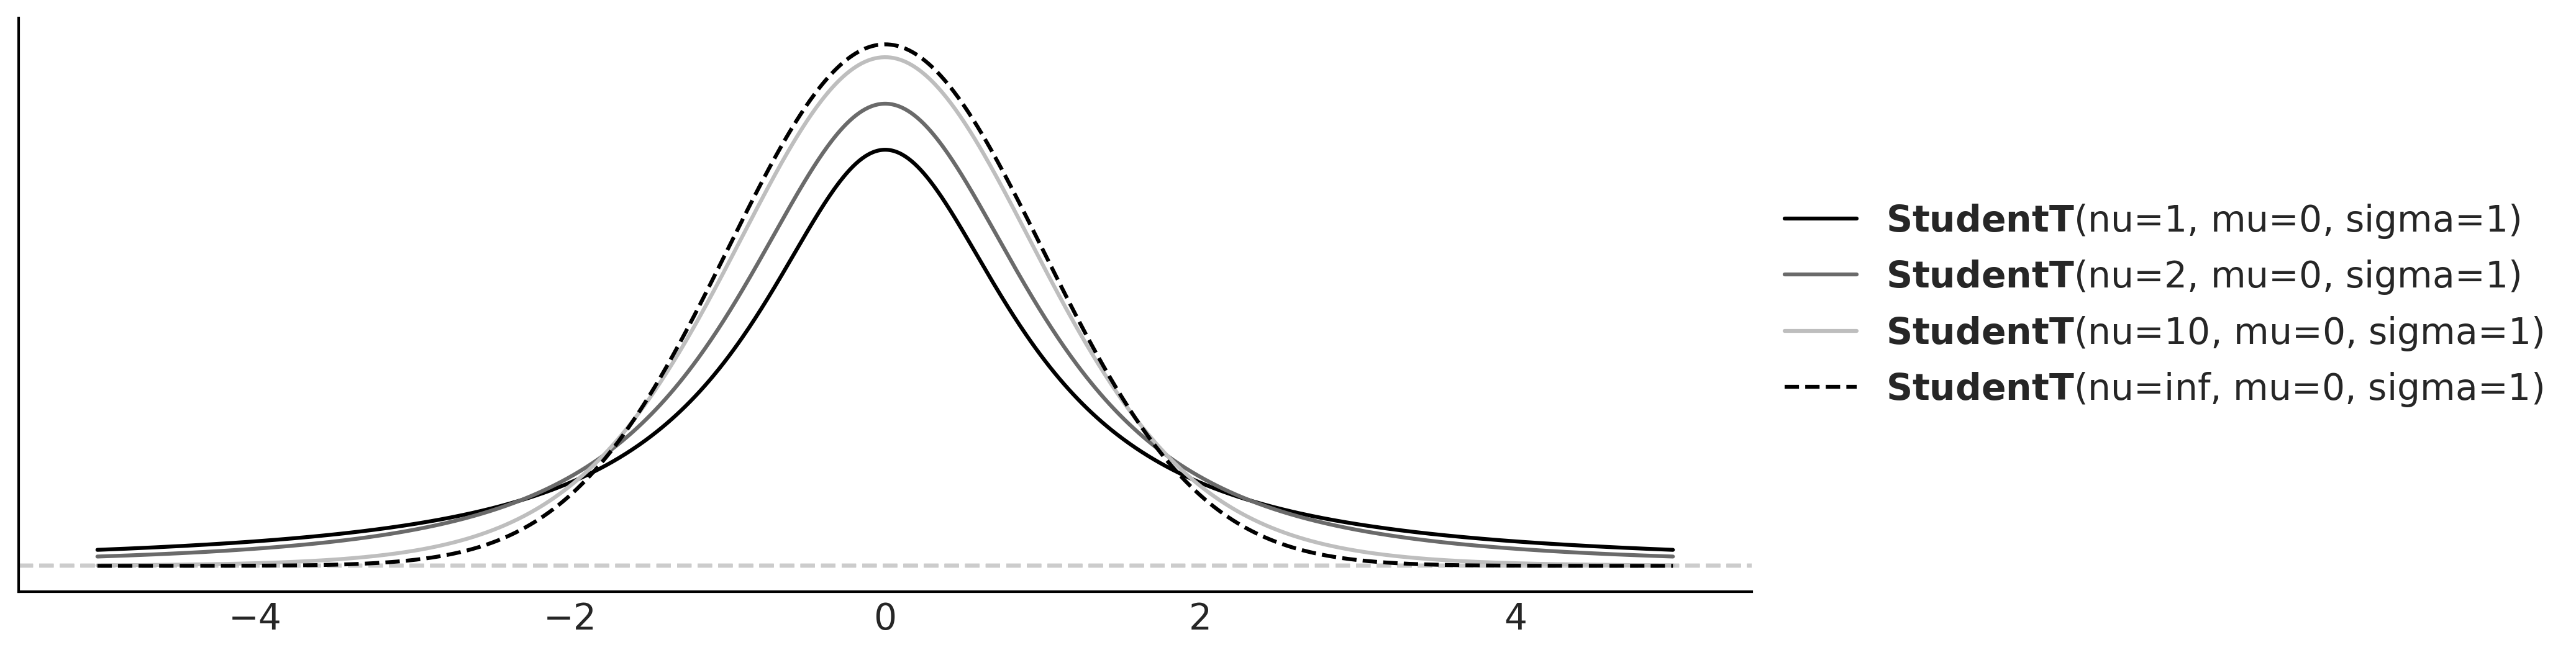

In [26]:
for nu in [1, 2, 10]:
    pz.StudentT(nu, 0, 1).plot_pdf(support=(-5, 5), figsize=(12, 4))

ax = pz.StudentT(np.inf, 0, 1).plot_pdf(support=(-5, 5), figsize=(12, 4), color='k')
ax.get_lines()[-1].set_linestyle('--')
pz.internal.plot_helper.side_legend(ax)
plt.savefig('fig/student_t.png')

In [27]:
with pm.Model() as model_t:
    µ = pm.Uniform('µ', lower=40, upper=70)
    σ = pm.HalfNormal('σ', sigma=10)
    v = pm.Exponential('v', 1/30)
    y = pm.StudentT('y', nu=v, mu=µ, sigma=σ, observed=data)
    idata_t = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [µ, σ, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


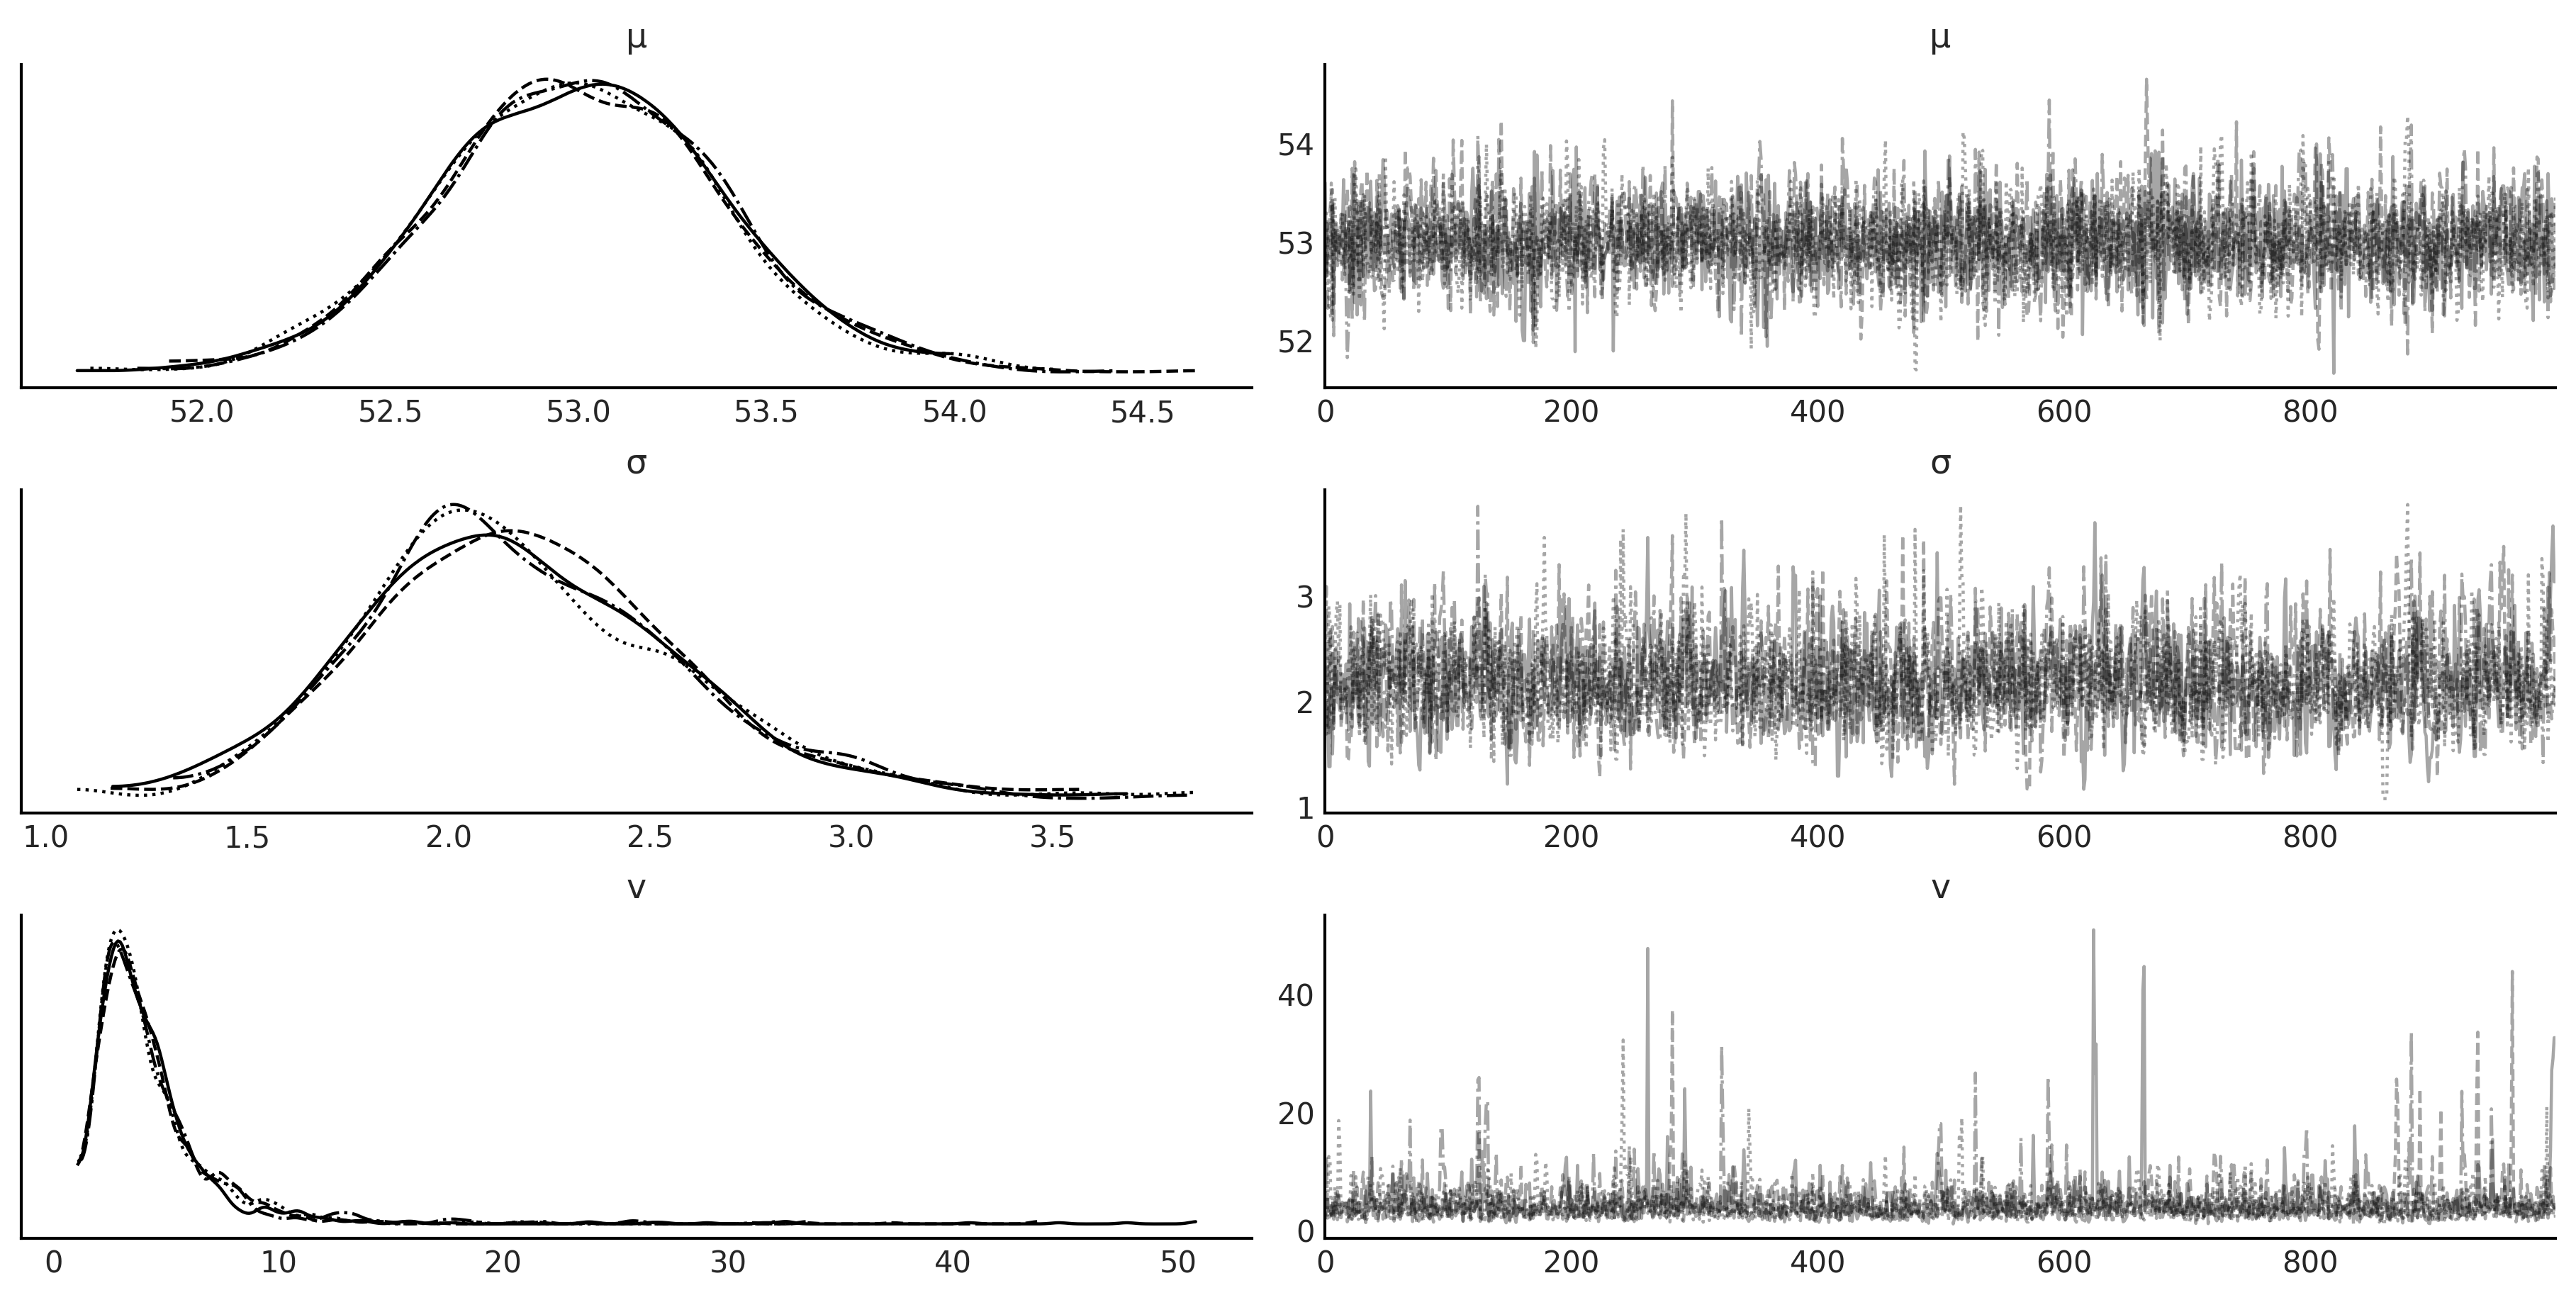

In [28]:
az.plot_trace(idata_t)
plt.savefig('fig/idata_t_trace.png')

In [30]:
az.summary(idata_t, kind='stats', round_to=2)

,mean,sd,hdi_3%,hdi_97%
µ,53.01,0.37,52.29,53.70
σ,2.18,0.39,1.45,2.90
v,4.45,3.35,1.24,8.98
